# Exercises in Data Transformation and Exploratory Data Analysis

This notebook contains the exercises for the class of February 5, 2025, in the course Data & Things at Roskilde University.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1

Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 

In [2]:
cinema_data = pd.read_csv('DK_cinemas.csv', sep=";")
years = cinema_data["Year"].tolist()
cinemas = cinema_data["Cinemas"].tolist()

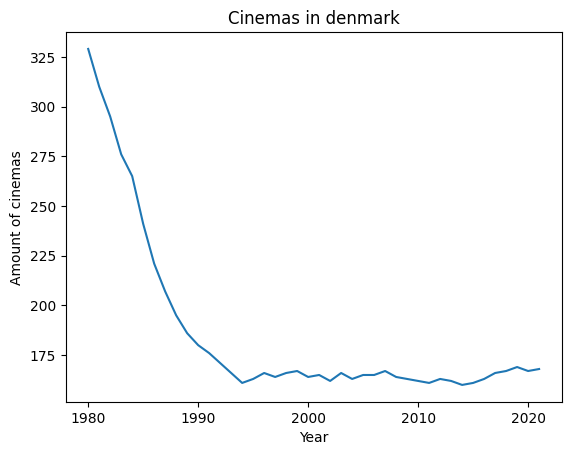

In [3]:
plt.plot(years, cinemas)
plt.ylabel('Amount of cinemas')
plt.xlabel('Year')
plt.title('Cinemas in denmark')
plt.show()

## Exercise 2

In this exercise, we are going to use the `penguins` dataset from the Seaborn package. The cell below loads the data

In [4]:
penguins_data = sns.load_dataset("penguins")

Based on the `Penguins` dataset, answer the following questions:

1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


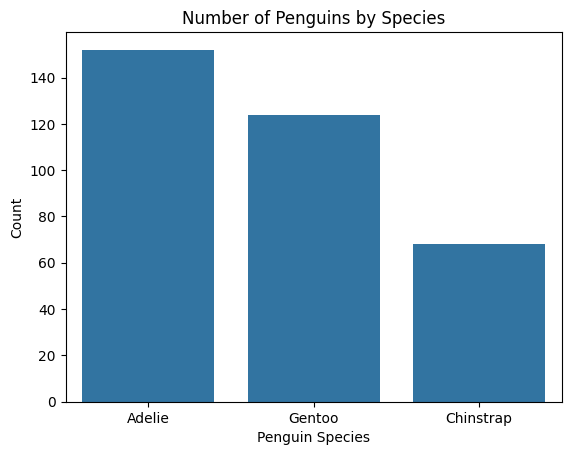

In [5]:
species_counts = penguins_data['species'].value_counts()
print(species_counts)

sns.barplot(x=species_counts.index, y=species_counts.values)
plt.xlabel('Penguin Species')
plt.ylabel('Count')
plt.title('Number of Penguins by Species')
plt.show()

2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers


species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


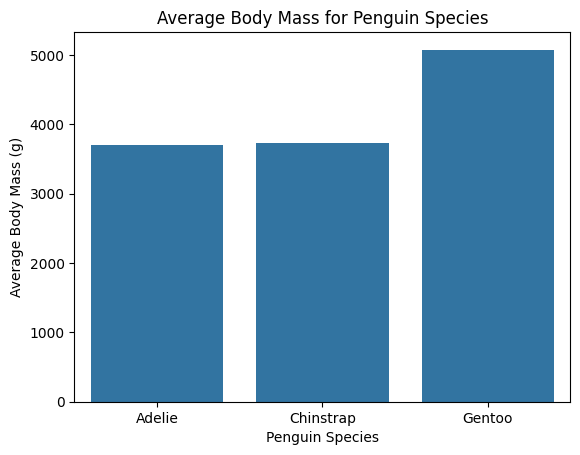

In [6]:
average_body_mass = penguins_data.groupby('species')['body_mass_g'].mean()
print(average_body_mass)

sns.barplot(x=average_body_mass.index, y=average_body_mass.values)
plt.xlabel('Penguin Species')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass for Penguin Species')
plt.show()

3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers. 


           count         mean         std     min     25%     50%     75%  \
species                                                                     
Adelie     151.0  3700.662252  458.566126  2850.0  3350.0  3700.0  4000.0   
Chinstrap   68.0  3733.088235  384.335081  2700.0  3487.5  3700.0  3950.0   
Gentoo     123.0  5076.016260  504.116237  3950.0  4700.0  5000.0  5500.0   

              max  
species            
Adelie     4775.0  
Chinstrap  4800.0  
Gentoo     6300.0  


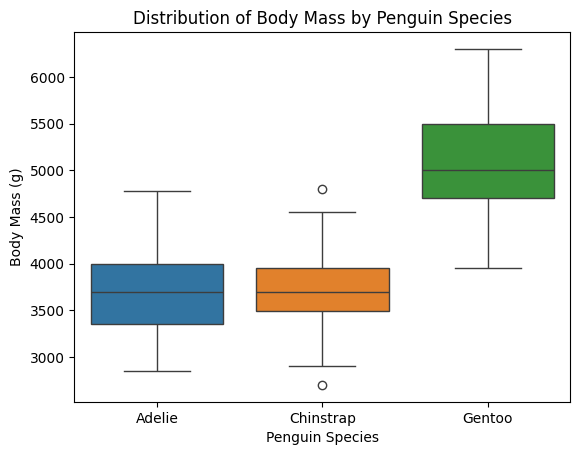

In [7]:
body_mass_stats = penguins_data.groupby('species')['body_mass_g'].describe()
print(body_mass_stats) 

sns.boxplot(x='species', y='body_mass_g', data=penguins_data, hue='species') 
plt.xlabel('Penguin Species') 
plt.ylabel('Body Mass (g)') 
plt.title('Distribution of Body Mass by Penguin Species') 
plt.show()

4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.


                   body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.871202
flipper_length_mm     0.871202           1.000000


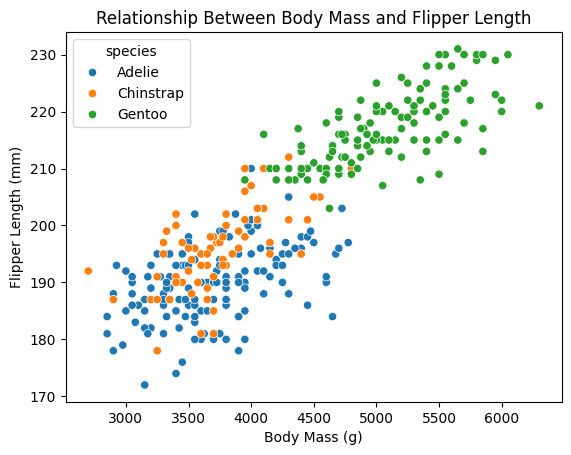

In [8]:
correlation = penguins_data[['body_mass_g', 'flipper_length_mm']].corr()
print(correlation)

sns.scatterplot(x='body_mass_g', y='flipper_length_mm', data=penguins_data, hue='species')
plt.xlabel('Body Mass (g)')
plt.ylabel('Flipper Length (mm)')
plt.title('Relationship Between Body Mass and Flipper Length')
plt.show()


5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.


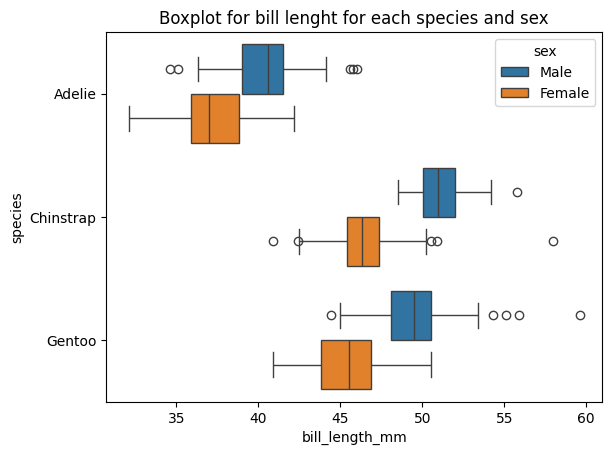

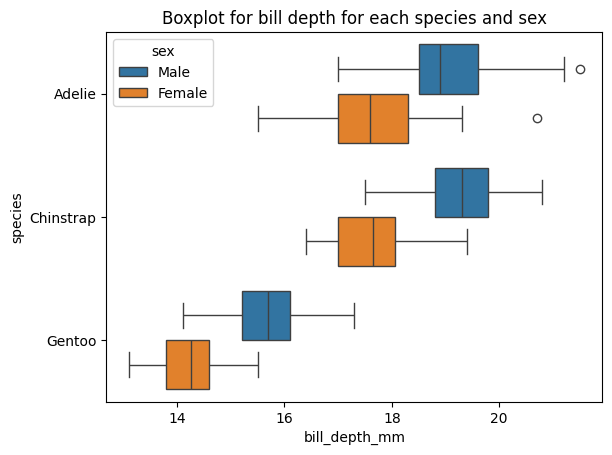

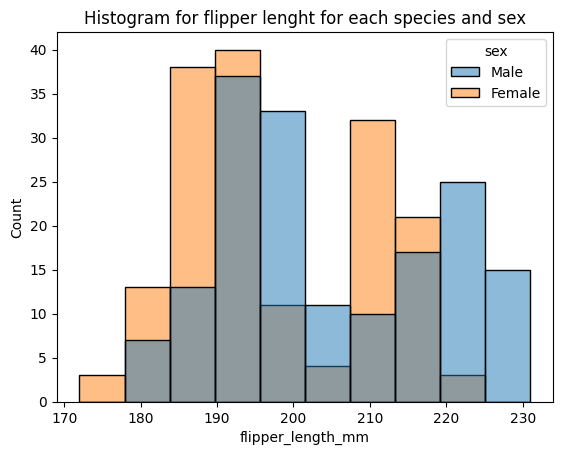

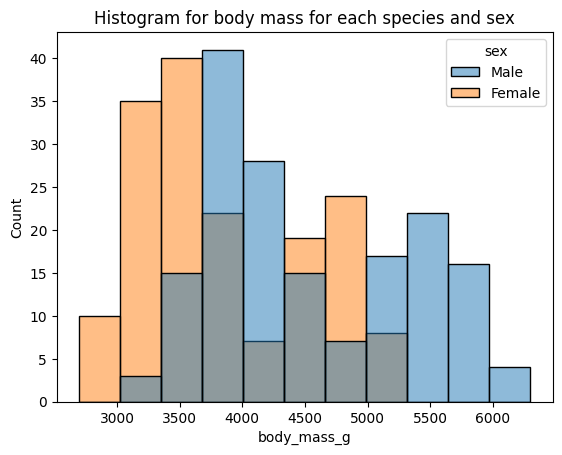

In [9]:
sns.boxplot(x='bill_length_mm', y='species', data=penguins_data, hue='sex')
plt.title('Boxplot for bill lenght for each species and sex')
plt.show()

sns.boxplot(x='bill_depth_mm', y='species', data=penguins_data, hue='sex')
plt.title('Boxplot for bill depth for each species and sex')
plt.show()

sns.histplot(x='flipper_length_mm', data=penguins_data, hue='sex')
plt.title('Histogram for flipper lenght for each species and sex')
plt.show()

sns.histplot(x='body_mass_g', data=penguins_data, hue='sex')
plt.title('Histogram for body mass for each species and sex')
plt.show()

6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.


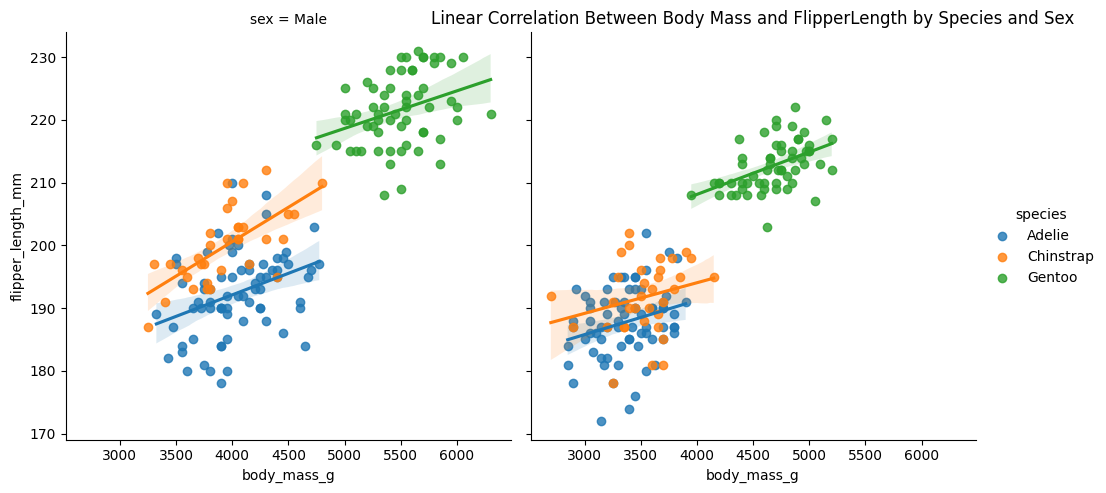

In [10]:
sns.lmplot(x='body_mass_g', y='flipper_length_mm', data=penguins_data, hue='species', col='sex')
plt.title('Linear Correlation Between Body Mass and FlipperLength by Species and Sex')
plt.show()      

## Exercise 3

Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)

In [11]:
from ucimlrepo import fetch_ucirepo 
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets 
X["income"] = y
adult_data = X.copy()

adult_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## Exercise 4 (Optional)

Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)

## Exercise 5 (Optional)

Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.

In [12]:
from sklearn.datasets import load_diabetes
d_data = load_diabetes(as_frame=True)
diabetes_data = d_data.data
diabetes_data["Target"] = d_data.target

diabetes_data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
